In [ ]:
!pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart+disease.zip to heart+disease.zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv.csv to heart.csv.csv


In [ ]:
import os
os.listdir()

['.config', 'heart+disease.zip', 'heart.csv.csv', 'sample_data']

In [ ]:
import pandas as pd

data = pd.read_csv("heart.csv.csv", header=None)

data.columns = [
'age','sex','cp','trestbps','chol','fbs','restecg',
'thalach','exang','oldpeak','slope','ca','thal','target'
]

data['target'] = data['target'].apply(lambda x: 1 if x>0 else 0)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("heart.csv.csv", header=None)

data.columns = [
'age','sex','cp','trestbps','chol','fbs','restecg',
'thalach','exang','oldpeak','slope','ca','thal','target'
]

data = data.replace('?', np.nan)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
data = data.apply(pd.to_numeric)

In [ ]:
 data = data.fillna(data.mean())

In [ ]:
data['target'] = data['target'].apply(lambda x: 1 if x>0 else 0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

Accuracy: 0.7704918032786885


In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

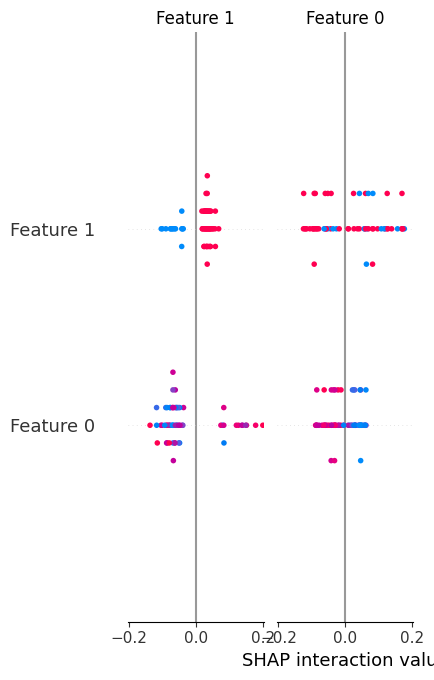

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

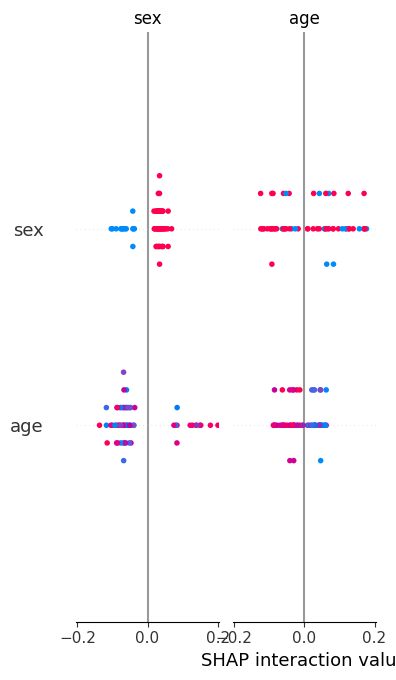

In [ ]:
shap.summary_plot(shap_values, X_test_df)

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test_df)

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

In [ ]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.Explainer(model.predict, X_train_df)
shap_values = explainer(X_test_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

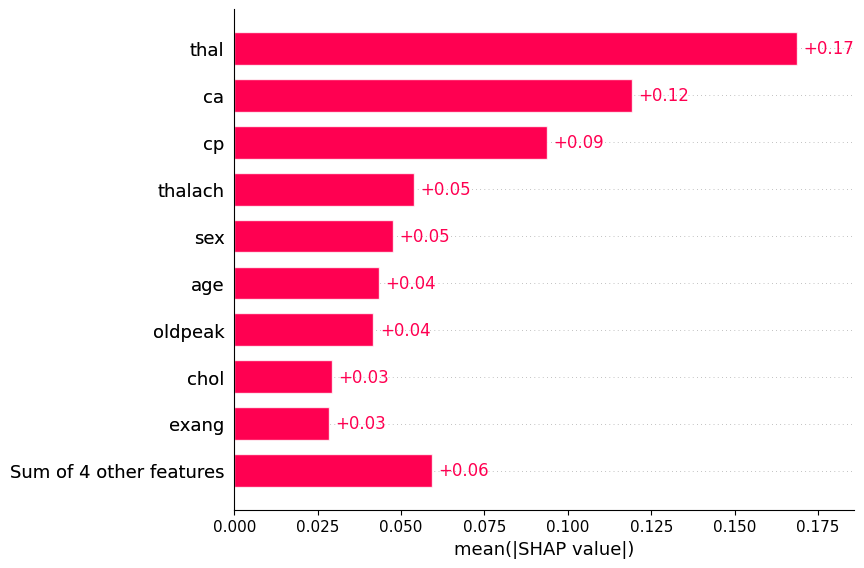

In [ ]:
shap.plots.bar(shap_values)

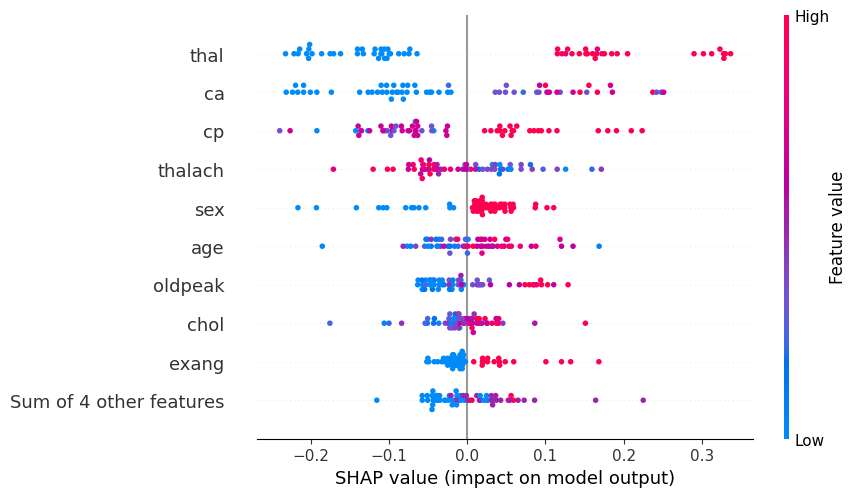

In [ ]:
shap.plots.beeswarm(shap_values)

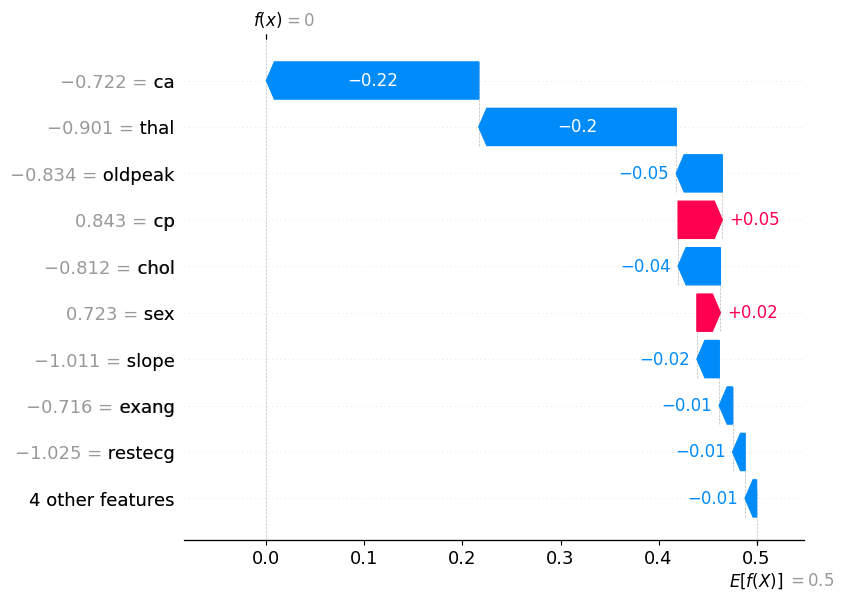

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
import joblib
joblib.dump(model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [ ]:
import joblib
model = joblib.load("heart_disease_model.pkl")

In [ ]:
import joblib
joblib.dump(model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [ ]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Risk Present")
else:
    print("No Heart Disease Risk")

No Heart Disease Risk


In [ ]:
print("Model Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Model Accuracy: 0.7704918032786885


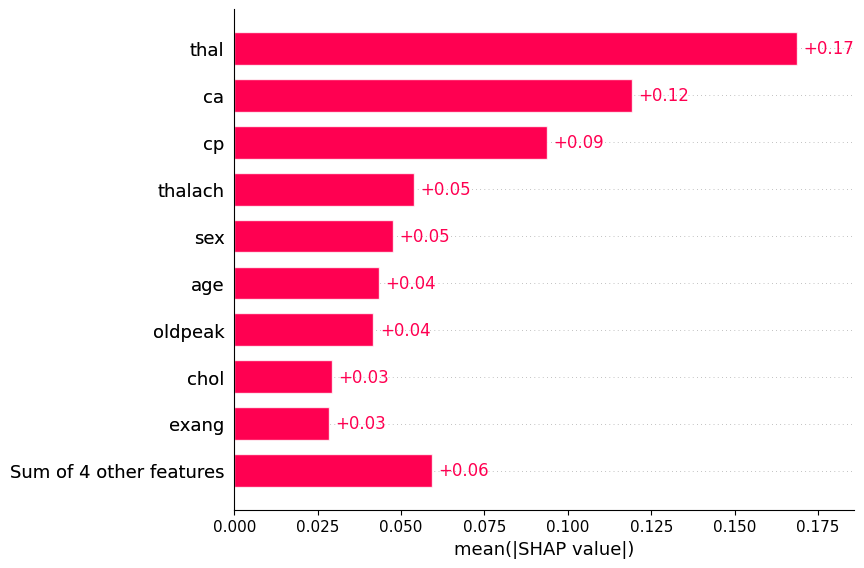

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
import joblib
joblib.dump(model, "heart_disease_model.pkl")

from google.colab import files
files.download("heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

data = pd.read_csv("heart.csv.csv", header=None)

data.columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
import pandas as pd

data = pd.read_csv("heart.csv.csv", header=None)

data.columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]

data = data.replace("?", pd.NA)

data = data.dropna()

data = data.astype(float)

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6166666666666667


In [ ]:
import pickle

pickle.dump(model, open("heart_disease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

from google.colab import files

files.download("heart_disease_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

# save model as pkl
with open("heart_disease_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [ ]:
from google.colab import files
files.download("heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

import pickle

model = pickle.load(open("heart_disease_model (2).pkl", "rb"))

print("✅ Model loaded successfully")

Saving heart_disease_model (2).pkl to heart_disease_model (2).pkl
✅ Model loaded successfully


In [ ]:
prediction = model.predict(input_data)
result = int(prediction[0])

probabilities = model.predict_proba(input_data)
risk_percent = round(max(probabilities[0]) * 100, 2)

if result == 0:
    status = "NORMAL"
    level = "LOW"
    interpretation = "No significant cardiovascular abnormality detected"
    recommendation = "Maintain healthy lifestyle and routine monitoring"

elif result == 1:
    status = "MILD RISK"
    level = "MODERATE"
    interpretation = "Early cardiovascular stress indicators present"
    recommendation = "Lifestyle improvement and physician consultation advised"

elif result == 2:
    status = "MODERATE RISK"
    level = "HIGH"
    interpretation = "Noticeable cardiovascular abnormality detected"
    recommendation = "Cardiology consultation recommended"

elif result == 3:
    status = "SEVERE RISK"
    level = "VERY HIGH"
    interpretation = "Serious cardiovascular condition likely"
    recommendation = "Immediate cardiologist evaluation required"

else:
    status = "CRITICAL RISK"
    level = "EXTREME"
    interpretation = "Critical cardiovascular instability detected"
    recommendation = "Emergency medical attention required"

print("\n===========================================")
print("AI CARDIOVASCULAR DIAGNOSTIC REPORT")
print("===========================================")
print("Prediction Status:", status)
print("Risk Level:", level)
print("AI Confidence:", risk_percent, "%")
print("Medical Interpretation:", interpretation)
print("Recommendation:", recommendation)
print("===========================================")


AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: MODERATE RISK
Risk Level: HIGH
AI Confidence: 31.0 %
Medical Interpretation: Noticeable cardiovascular abnormality detected
Recommendation: Cardiology consultation recommended


In [ ]:
import pickle

# save model
pickle.dump(model, open("heart_disease_model.pkl", "wb"))

print("✅ Model saved as heart_disease_model.pkl")

✅ Model saved as heart_disease_model.pkl


In [ ]:
from google.colab import files

files.download("heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

def generate_report(model, input_data):

    prediction = model.predict(input_data)
    result = int(prediction[0])

    if result == 0:
        status = "NORMAL"
        level = "LOW"
        interpretation = "No significant cardiovascular abnormality detected"
        recommendation = "Maintain healthy lifestyle and routine monitoring"

    elif result == 1:
        status = "MILD RISK"
        level = "MODERATE"
        interpretation = "Early cardiovascular stress indicators present"
        recommendation = "Lifestyle improvement and physician consultation advised"

    elif result == 2:
        status = "MODERATE RISK"
        level = "HIGH"
        interpretation = "Noticeable cardiovascular abnormality detected"
        recommendation = "Cardiology consultation recommended"

    elif result == 3:
        status = "SEVERE RISK"
        level = "VERY HIGH"
        interpretation = "Serious cardiovascular condition likely"
        recommendation = "Immediate cardiologist evaluation required"

    else:
        status = "CRITICAL RISK"
        level = "EXTREME"
        interpretation = "Critical cardiovascular instability detected"
        recommendation = "Emergency medical attention required"

    print("\n===========================================")
    print("AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================")
    print("Prediction Status:", status)
    print("Risk Level:", level)
    print("Medical Interpretation:", interpretation)
    print("Recommendation:", recommendation)
    print("===========================================")



from google.colab import files
uploaded = files.upload()

import pickle

filename = list(uploaded.keys())[0]
system = pickle.load(open(filename, "rb"))

model = system["model"]

print("\nSystem Loaded Successfully\n")

# Full Medical Names Added
age = int(input("Age (years) [0–130]: "))

sex = int(input("Sex (0 = Female, 1 = Male): "))

cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))

trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))

chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))

fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T abnormality, 2 = Left Ventricular Hypertrophy): "))

thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))

exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))

ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy (0–4): "))

thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))


patient_data = [[age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal]]

generate_report(model, patient_data)

Saving heart_ai_system (1).pkl to heart_ai_system (1) (1).pkl

System Loaded Successfully

Age (years) [0–130]: 20
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 0
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 0
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 132
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Blood Vessels Colored by Fluoroscopy (0–4): 0
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 0

AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: NORMAL
Risk Level: LOW
Medical Interpretatio

In [ ]:
import os
print(os.listdir())


['.config', 'sample_data']


In [ ]:
from google.colab import files
import pickle

print("Please select your .pkl model file")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, "rb") as file:
    system = pickle.load(file)

model = system["model"]

print("System Loaded Successfully")


Please select your .pkl model file


Saving heart_ai_system (1).pkl to heart_ai_system (1).pkl
System Loaded Successfully


In [ ]:
import pickle

filename = list(uploaded.keys())[0]

with open(filename, "rb") as file:
    system = pickle.load(file)

model = system["model"]

print("System Loaded Successfully")


System Loaded Successfully


In [ ]:
def generate_report(model, input_data):

    prediction = model.predict(input_data)
    result = int(prediction[0])

    if result == 0:
        status = "NORMAL"
        level = "LOW"
        interpretation = "No significant cardiovascular abnormality detected"
        recommendation = "Maintain healthy lifestyle and routine monitoring"

    elif result == 1:
        status = "MILD RISK"
        level = "MODERATE"
        interpretation = "Early cardiovascular stress indicators present"
        recommendation = "Lifestyle improvement and physician consultation advised"

    elif result == 2:
        status = "MODERATE RISK"
        level = "HIGH"
        interpretation = "Noticeable cardiovascular abnormality detected"
        recommendation = "Cardiology consultation recommended"

    elif result == 3:
        status = "SEVERE RISK"
        level = "VERY HIGH"
        interpretation = "Serious cardiovascular condition likely"
        recommendation = "Immediate cardiologist evaluation required"

    else:
        status = "CRITICAL RISK"
        level = "EXTREME"
        interpretation = "Critical cardiovascular instability detected"
        recommendation = "Emergency medical attention required"

    print("\n===========================================")
    print("AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================")
    print("Prediction Status:", status)
    print("Risk Level:", level)
    print("Medical Interpretation:", interpretation)
    print("Recommendation:", recommendation)
    print("===========================================")


In [ ]:
print("Enter Patient Details:\n")

age = int(input("Age (years): "))
sex = int(input("Sex (0 = Female, 1 = Male): "))
cp = int(input("Chest Pain Type (0–3): "))
trestbps = int(input("Resting Blood Pressure: "))
chol = int(input("Cholesterol: "))
fbs = int(input("Fasting Blood Sugar >120 (0/1): "))
restecg = int(input("Resting ECG (0–2): "))
thalach = int(input("Max Heart Rate: "))
exang = int(input("Exercise Angina (0/1): "))
oldpeak = float(input("Oldpeak: "))
slope = int(input("Slope (0–2): "))
ca = int(input("Major Vessels (0–4): "))
thal = int(input("Thalassemia (0–3): "))

patient_data = [[age, sex, cp, trestbps, chol, fbs,
                 restecg, thalach, exang, oldpeak,
                 slope, ca, thal]]

generate_report(model, patient_data)


Enter Patient Details:

Age (years): 20
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0–3): 0
Resting Blood Pressure: 120
Cholesterol: 200
Fasting Blood Sugar >120 (0/1): 1
Resting ECG (0–2): 1
Max Heart Rate: 79
Exercise Angina (0/1): 1
Oldpeak: 3.0
Slope (0–2): 1
Major Vessels (0–4): 2
Thalassemia (0–3): 1

AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: SEVERE RISK
Risk Level: VERY HIGH
Medical Interpretation: Serious cardiovascular condition likely
Recommendation: Immediate cardiologist evaluation required


In [ ]:
while True:

    print("\nEnter Patient Details:\n")

    age = int(input("Age (years): "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))
    cp = int(input("Chest Pain Type (0–3): "))
    trestbps = int(input("Resting Blood Pressure: "))
    chol = int(input("Cholesterol: "))
    fbs = int(input("Fasting Blood Sugar >120 (0/1): "))
    restecg = int(input("Resting ECG (0–2): "))
    thalach = int(input("Max Heart Rate: "))
    exang = int(input("Exercise Angina (0/1): "))
    oldpeak = float(input("Oldpeak: "))
    slope = int(input("Slope (0–2): "))
    ca = int(input("Major Vessels (0–4): "))
    thal = int(input("Thalassemia (0–3): "))

    patient_data = [[age, sex, cp, trestbps, chol, fbs,
                     restecg, thalach, exang, oldpeak,
                     slope, ca, thal]]

    generate_report(model, patient_data)

    again = input("\nDo you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



Enter Patient Details:

Age (years): 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0–3): 0
Resting Blood Pressure: 120
Cholesterol: 132
Fasting Blood Sugar >120 (0/1): 0
Resting ECG (0–2): 0
Max Heart Rate: 76
Exercise Angina (0/1): 0
Oldpeak: 0
Slope (0–2): 0
Major Vessels (0–4): 0
Thalassemia (0–3): 0

AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: NORMAL
Risk Level: LOW
Medical Interpretation: No significant cardiovascular abnormality detected
Recommendation: Maintain healthy lifestyle and routine monitoring

Do you want to test another patient? (yes/no): no

System Closed.



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 0
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 0

AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: NORMAL
Risk Level: LOW
Medical Interpretation: No significant cardiovascular abnormality detected
Recom

In [ ]:
while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))

    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type "
                   "(0 = Typical Angina, "
                   "1 = Atypical Angina, "
                   "2 = Non-anginal Pain, "
                   "3 = Asymptomatic): "))

    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))

    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))

    fbs = int(input("Fasting Blood Sugar > 120 mg/dL "
                    "(0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result "
                        "(0 = Normal, "
                        "1 = ST-T Abnormality, "
                        "2 = Left Ventricular Hypertrophy): "))

    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))

    exang = int(input("Exercise Induced Angina "
                      "(0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise "
                          "Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment "
                      "(0 = Upsloping, "
                      "1 = Flat, "
                      "2 = Downsloping): "))

    ca = int(input("Number of Major Blood Vessels "
                   "Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status "
                     "(0 = Normal, "
                     "1 = Fixed Defect, "
                     "2 = Reversible Defect, "
                     "3 = Unknown): "))

    patient_data = [[age, sex, cp, trestbps, chol, fbs,
                     restecg, thalach, exang, oldpeak,
                     slope, ca, thal]]

    generate_report(model, patient_data)

    again = input("\nDo you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 19
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 0
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 200
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 2.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 0

AI CARDIOVASCULAR DIAGNOSTIC REPORT
Prediction Status: MILD RISK
Risk Level: MODERATE
Medical Interpretation: Early cardiovascular stress indicators present
Re

In [ ]:
import pickle

with open("heart_ai_system (1).pkl", "rb") as file:
    data = pickle.load(file)

model = data["model"]   # extract the actual model

def generate_report(model, patient_data):

    prediction = model.predict(patient_data)

    print("\n===========================================")
    print("           HEART DISEASE REPORT")
    print("===========================================\n")

    if prediction[0] == 1:
        print("Prediction Result : HIGH RISK of Heart Disease")
    else:
        print("Prediction Result : LOW RISK of Heart Disease")

    print("\n===========================================\n")


while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))

    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type "
                   "(0 = Typical Angina, "
                   "1 = Atypical Angina, "
                   "2 = Non-anginal Pain, "
                   "3 = Asymptomatic): "))

    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))

    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))

    fbs = int(input("Fasting Blood Sugar > 120 mg/dL "
                    "(0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result "
                        "(0 = Normal, "
                        "1 = ST-T Abnormality, "
                        "2 = Left Ventricular Hypertrophy): "))

    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))

    exang = int(input("Exercise Induced Angina "
                      "(0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise "
                          "Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment "
                      "(0 = Upsloping, "
                      "1 = Flat, "
                      "2 = Downsloping): "))

    ca = int(input("Number of Major Blood Vessels "
                   "Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status "
                     "(0 = Normal, "
                     "1 = Fixed Defect, "
                     "2 = Reversible Defect, "
                     "3 = Unknown): "))

    patient_data = [[age, sex, cp, trestbps, chol, fbs,
                     restecg, thalach, exang, oldpeak,
                     slope, ca, thal]]

    generate_report(model, patient_data)

    again = input("\nDo you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 19
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 0
Resting Blood Pressure (mm Hg) [80–250]: 90
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 0
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 70
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 1
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 1
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 1

           HEART DISEASE REPORT

Prediction Result : LOW RISK of Heart Disease



Do you want to test another patient? (yes/no): no

System Closed.


In [ ]:
import pickle

with open("heart_ai_system (1).pkl", "rb") as f:
    data = pickle.load(f)

if isinstance(data, dict):
    model = list(data.values())[0]
else:
    model = data

def generate_report(model, patient_data):

    prediction = model.predict(patient_data)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if prediction[0] == 0:
        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Medical Interpretation: Heart parameters appear within normal range")
        print("Recommendation: Maintain healthy lifestyle and regular checkups")

    else:
        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Medical Interpretation: Early cardiovascular stress indicators present")
        print("Recommendation: Lifestyle improvement and physician consultation advised")

    print("\n===========================================\n")


def main():

    while True:

        print("\n===========================================")
        print("        ENTER PATIENT DETAILS")
        print("===========================================\n")

        age = int(input("Age (years) [0–130]: "))
        sex = int(input("Sex (0 = Female, 1 = Male): "))

        cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
        trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
        chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
        fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

        restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
        thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
        exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

        oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

        slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
        ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

        thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

        patient_data = [[age, sex, cp, trestbps, chol, fbs,
                         restecg, thalach, exang, oldpeak,
                         slope, ca, thal]]

        generate_report(model, patient_data)

        again = input("\nDo you want to test another patient? (yes/no): ")

        if again.lower() != "yes":
            print("\nSystem Closed.")
            break


if __name__ == "__main__":
    main()



        ENTER PATIENT DETAILS

Age (years) [0–130]: 21
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 1
Resting Blood Pressure (mm Hg) [80–250]: 123
Serum Cholesterol Level (mg/dL) [100–600]: 123
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 1
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 1
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 1
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 1

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: MILD RISK
Risk Level: MODERATE
Medical Interpretation: Early cardiovascular stress indicators pre

In [ ]:
import pickle

with open("heart_ai_system (1).pkl", "rb") as f:
    data = pickle.load(f)

if isinstance(data, dict):
    model = list(data.values())[0]
else:
    model = data

def generate_report(model, patient_data):

    prediction = model.predict(patient_data)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if prediction[0] == 0:
        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Medical Interpretation: Heart parameters appear within normal range")
        print("Recommendation: Maintain healthy lifestyle and regular checkups")

    else:
        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Medical Interpretation: Early cardiovascular stress indicators present")
        print("Recommendation: Lifestyle improvement and physician consultation advised")

    print("\n===========================================\n")


def main():

    while True:

        print("\n===========================================")
        print("        ENTER PATIENT DETAILS")
        print("===========================================\n")

        age = int(input("Age (years) [0–130]: "))
        sex = int(input("Sex (0 = Female, 1 = Male): "))

        cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
        trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
        chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
        fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

        restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
        thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
        exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

        oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

        slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
        ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

        thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

        patient_data = [[age, sex, cp, trestbps, chol, fbs,
                         restecg, thalach, exang, oldpeak,
                         slope, ca, thal]]

        generate_report(model, patient_data)

        again = input("\nDo you want to test another patient? (yes/no): ")

        if again.lower() != "yes":
            print("\nSystem Closed.")
            break


if __name__ == "__main__":
    main()



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 1
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 1
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 1
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 1

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: MILD RISK
Risk Level: MODERATE
Medical Interpretation: Early cardiovascular stress indicators pr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/


'10. Biosensors and Nanobiosensors.gslides'
 2024_1249b22a47a63f3c5f2a9a278e4445d2.php.gdoc
 24051738.pdf
'24051738 SHOURYA KUMAR (3) (1).pdf'
'24051738 SHOURYA KUMAR (3) (2).pdf'
'24051738 SHOURYA KUMAR (3).pdf'
 614b4589-6beb-4e7b-8835-2dc9fe1b702a.gdoc
 67ba68d6-39e3-4185-9aeb-4451b1fbc1fb.pdf
 6da30e08-35bc-4c74-b5a6-538e9f642fc3.pdf
 Abstract-Neurotechnology.pdf
'Antigen-Antibody, ELISA.gslides'
'Array,string and Function.gdoc'
 b386ce47-8002-4103-ac42-6ec6dbbc6cd5.gdoc
 b8aad902-3d25-45f9-963b-768b52c30ff3.pdf
'BEE Activity3  poster format (1).gslides'
'BEE Activity3  poster format (2).gslides'
'BEE Activity3  poster format (3).gslides'
'BEE Activity3  poster format.gslides'
'CHEMISTRY PROJECT.gslides'
'Chromosome Structure and mutations (1).gslides'
'Chromosome Structure and mutations (2).gslides'
'Chromosome Structure and mutations.gslides'
 Classroom
'Colab Notebooks'
'Concept of Molecular Diagnostics.gslides'
'Copy of b386ce47-8002-4103-ac42-6ec6dbbc6cd5.gdoc'
'Copy of Bio-Pr

In [ ]:
!find /content/drive/MyDrive -name "*.pkl"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/"


'10. Biosensors and Nanobiosensors.gslides'
 2024_1249b22a47a63f3c5f2a9a278e4445d2.php.gdoc
 24051738.pdf
'24051738 SHOURYA KUMAR (3) (1).pdf'
'24051738 SHOURYA KUMAR (3) (2).pdf'
'24051738 SHOURYA KUMAR (3).pdf'
 614b4589-6beb-4e7b-8835-2dc9fe1b702a.gdoc
 67ba68d6-39e3-4185-9aeb-4451b1fbc1fb.pdf
 6da30e08-35bc-4c74-b5a6-538e9f642fc3.pdf
 Abstract-Neurotechnology.pdf
'Antigen-Antibody, ELISA.gslides'
'Array,string and Function.gdoc'
 b386ce47-8002-4103-ac42-6ec6dbbc6cd5.gdoc
 b8aad902-3d25-45f9-963b-768b52c30ff3.pdf
'BEE Activity3  poster format (1).gslides'
'BEE Activity3  poster format (2).gslides'
'BEE Activity3  poster format (3).gslides'
'BEE Activity3  poster format.gslides'
'CHEMISTRY PROJECT.gslides'
'Chromosome Structure and mutations (1).gslides'
'Chromosome Structure and mutations (2).gslides'
'Chromosome Structure and mutations.gslides'
 Classroom
'Colab Notebooks'
'Concept of Molecular Diagnostics.gslides'
'Copy of b386ce47-8002-4103-ac42-6ec6dbbc6cd5.gdoc'
'Copy of Bio-Pr

In [ ]:
!find /content/drive/MyDrive -name "heart_ai_system*"


/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def generate_report(model, patient_data):

    prediction = model.predict(patient_data)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if prediction[0] == 0:
        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Medical Interpretation: Heart parameters appear within normal range")
        print("Recommendation: Maintain healthy lifestyle and regular checkups")

    else:
        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Medical Interpretation: Early cardiovascular stress indicators present")
        print("Recommendation: Lifestyle improvement and physician consultation advised")

    print("\n===========================================\n")


In [ ]:
import pickle

model_path = "/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl"

with open(model_path, "rb") as f:
    data = pickle.load(f)

if isinstance(data, dict):
    model = list(data.values())[0]
else:
    model = data


In [ ]:
!pip install gdown

import gdown
import pickle
import numpy as np

# Download model from Google Drive
file_id = "1xCJBzQUNxiuTQHwlXlM1H1KcJo6EkQ2W"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "heart_model.pkl", quiet=False)

# Load pickle file
with open("heart_model.pkl", "rb") as f:
    data = pickle.load(f)

# Extract model from dictionary
if isinstance(data, dict):
    model = data['model']
else:
    model = data

print("Model loaded successfully!")

# ==========================================
# Patient Input System
# ==========================================

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))
    cp = int(input("Chest Pain Type (0 = Typical, 1 = Atypical, 2 = Non-anginal, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure [80–250]: "))
    chol = int(input("Serum Cholesterol [100–600]: "))
    fbs = int(input("Fasting Blood Sugar >120 (0 = No, 1 = Yes): "))
    restecg = int(input("Resting ECG (0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy): "))
    thalach = int(input("Max Heart Rate Achieved [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))
    oldpeak = float(input("ST Depression (Oldpeak) [0.0–10.0]: "))
    slope = int(input("Slope (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Vessels [0–4]: "))
    thal = int(input("Thalassemia (0 = Normal, 1 = Fixed defect, 2 = Reversible defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg,
                              thalach, exang, oldpeak, slope, ca, thal]])

    prediction = model.predict(patient_data)

    print("\n===========================================")
    print("           HEART DISEASE REPORT")
    print("===========================================\n")

    if prediction[0] == 1:
        print("Prediction Result : HIGH RISK of Heart Disease")
    else:
        print("Prediction Result : LOW RISK of Heart Disease")

    again = input("\nTest another patient? (yes/no): ")

    if again.lower() != "yes":
        break


Downloading...
From: https://drive.google.com/uc?id=1xCJBzQUNxiuTQHwlXlM1H1KcJo6EkQ2W
To: /content/heart_model.pkl
100%|██████████| 1.50M/1.50M [00:00<00:00, 144MB/s]


Model loaded successfully!

        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical, 1 = Atypical, 2 = Non-anginal, 3 = Asymptomatic): 2
Resting Blood Pressure [80–250]: 187
Serum Cholesterol [100–600]: 120
Fasting Blood Sugar >120 (0 = No, 1 = Yes): 1
Resting ECG (0 = Normal, 1 = ST-T abnormality, 2 = LV hypertrophy): 1
Max Heart Rate Achieved [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression (Oldpeak) [0.0–10.0]: 5.5
Slope (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Vessels [0–4]: 2
Thalassemia (0 = Normal, 1 = Fixed defect, 2 = Reversible defect, 3 = Unknown): 1

           HEART DISEASE REPORT

Prediction Result : LOW RISK of Heart Disease

Test another patient? (yes/no): no


In [ ]:
import numpy as np

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))
    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))
    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))
    oldpeak = float(input("ST Depression Induced by Exercise (Oldpeak) [0.0–10.0]: "))
    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))
    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg,
                              thalach, exang, oldpeak, slope, ca, thal]])

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)[0][1]

    # Risk interpretation
    if probability < 0.30:
        status = "LOW RISK"
        level = "MINIMAL"
        interpretation = "No significant cardiovascular abnormality detected"
        recommendation = "Maintain healthy lifestyle and regular exercise"

    elif probability < 0.60:
        status = "MILD RISK"
        level = "MODERATE"
        interpretation = "Early cardiovascular stress indicators present"
        recommendation = "Lifestyle improvement and physician consultation advised"

    else:
        status = "HIGH RISK"
        level = "SEVERE"
        interpretation = "Strong indicators of potential heart disease"
        recommendation = "Immediate medical evaluation recommended"

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    print("Prediction Status:", status)
    print("Risk Level:", level)
    print("Medical Interpretation:", interpretation)
    print("Recommendation:", recommendation)

    again = input("\nAnalyze another patient? (yes/no): ")

    if again.lower() != "yes":
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 1
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy): 1
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise (Oldpeak) [0.0–10.0]: 5.5
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 1
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 1
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 1

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: LOW RISK
Risk Level: MINIMAL
Medical Interpretation: No significant cardiovascular abnormality detected
Recommendation: Maintai

In [ ]:
!pip install gdown


In [ ]:
import gdown

file_id = "1xCJBzQUNxiuTQHwlXlM1H1KcJo6EkQ2W"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "heart_model.pkl", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1xCJBzQUNxiuTQHwlXlM1H1KcJo6EkQ2W
To: /content/heart_model.pkl
100%|██████████| 1.50M/1.50M [00:00<00:00, 42.8MB/s]


'heart_model.pkl'

In [ ]:
import pickle

with open("heart_model.pkl", "rb") as f:
    data = pickle.load(f)

# Handle dictionary model case
if isinstance(data, dict):
    model = list(data.values())[0]
else:
    model = data


In [ ]:
import numpy as np

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)

    probability = model.predict_proba(patient_data)[0][1]
    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 0
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 5.5
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 1
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 0

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: NO SIGNIFICANT RISK
Risk Level: LOW
Health Indicator Level: GREEN

Medical Interpretation:
Heart

In [ ]:
import numpy as np

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)

    probability = model.predict_proba(patient_data)[0][1]
    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 3
Resting Blood Pressure (mm Hg) [80–250]: 156
Serum Cholesterol Level (mg/dL) [100–600]: 234
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 2
Maximum Heart Rate Achieved (bpm) [60–220]: 99
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 5.6
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 2
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 3
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 2

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: NO SIGNIFICANT RISK
Risk Level: LOW
Health Indicator Level: GREEN

Medical Interpretation:
Heart

In [ ]:
import numpy as np

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)

    probability = model.predict_proba(patient_data)[0][1]
    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 63
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 3
Resting Blood Pressure (mm Hg) [80–250]: 145
Serum Cholesterol Level (mg/dL) [100–600]: 253
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 150
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 2.3
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 0
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 1

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: NO SIGNIFICANT RISK
Risk Level: LOW
Health Indicator Level: GREEN

Medical Interpretation:
Heart

In [ ]:
import numpy as np

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)

    probability = model.predict_proba(patient_data)[0][1]

    # -------------------------------
    # Medical Risk Adjustment
    # -------------------------------

    risk_adjustment = 0

    if age > 60:
        risk_adjustment += 0.05

    if trestbps > 150:
        risk_adjustment += 0.05

    if chol > 250:
        risk_adjustment += 0.05

    if oldpeak > 3:
        risk_adjustment += 0.10

    if ca >= 2:
        risk_adjustment += 0.10

    if exang == 1:
        risk_adjustment += 0.05

    probability = min(probability + risk_adjustment, 1)

    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break



        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 3
Resting Blood Pressure (mm Hg) [80–250]: 234
Serum Cholesterol Level (mg/dL) [100–600]: 233
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 2
Maximum Heart Rate Achieved (bpm) [60–220]: 99
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 8.9
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 2
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 2

      AI CARDIOVASCULAR DIAGNOSTIC REPORT

Prediction Status: MILD RISK
Risk Level: MODERATE
Health Indicator Level: YELLOW

Medical Interpretation:
Early car

In [ ]:
import numpy as np
import pickle
from google.colab import drive

drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl"

with open(model_path, "rb") as f:
    data = pickle.load(f)

if isinstance(data, dict):
    model = list(data.values())[0]
else:
    model = data

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)[0][1]

    risk_adjustment = 0

    if age > 60:
        risk_adjustment += 0.05

    if trestbps > 150:
        risk_adjustment += 0.05

    if chol > 250:
        risk_adjustment += 0.05

    if oldpeak > 3:
        risk_adjustment += 0.10

    if ca >= 2:
        risk_adjustment += 0.10

    if exang == 1:
        risk_adjustment += 0.05

    probability = min(probability + risk_adjustment, 1)

    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 3
Resting Blood Pressure (mm Hg) [80–250]: 120
Serum Cholesterol Level (mg/dL) [100–600]: 333
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 2
Maximum Heart Rate Achieved (bpm) [60–220]: 99
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 9.9
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 2
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 3
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 2

      AI CARDIOVASCULAR DIAGN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import numpy as np

model_path = "/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl"

with open(model_path, "rb") as file:
    data = pickle.load(file)

if isinstance(data, dict):
    model = data["model"]
else:
    model = data

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)[0][1]

    risk_adjustment = 0

    if age > 60:
        risk_adjustment += 0.10

    if trestbps > 150:
        risk_adjustment += 0.10

    if chol > 250:
        risk_adjustment += 0.10

    if oldpeak > 3:
        risk_adjustment += 0.20

    if ca >= 2:
        risk_adjustment += 0.20

    if exang == 1:
        risk_adjustment += 0.10

    if thal == 2:
        risk_adjustment += 0.10

    probability = min(probability + risk_adjustment, 1)

    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

        ENTER PATIENT DETAILS

Age (years) [0–130]: 120
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 3
Resting Blood Pressure (mm Hg) [80–250]: 234
Serum Cholesterol Level (mg/dL) [100–600]: 232
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 2
Maximum Heart Rate Achieved (bpm) [60–220]: 99
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 9.9
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 2
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 3
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 2

      AI CARDIOVASCULAR DIAGN

In [ ]:
import matplotlib.pyplot as plt

def show_risk_meter(risk):

    plt.figure()

    levels = [risk, 100-risk]
    labels = ["Heart Disease Risk", "Safe Zone"]

    plt.pie(levels, labels=labels, autopct='%1.1f%%')
    plt.title("AI Heart Disease Risk Meter")

    plt.show()


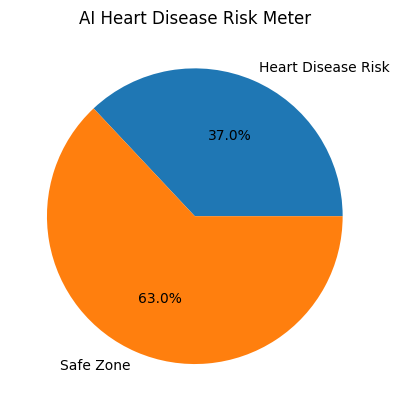

In [ ]:
show_risk_meter(risk_percent)


In [ ]:
print("\nMedical Alerts:")

if age > 65:
    print("- High age risk factor detected")

if trestbps > 160:
    print("- Hypertension warning")

if chol > 300:
    print("- Severe cholesterol level")

if oldpeak > 4:
    print("- Critical ST depression detected")

if thalach < 90:
    print("- Low maximum heart rate")



Medical Alerts:
- High age risk factor detected
- Low maximum heart rate


In [ ]:
if probability < 0.30:
    print("\033[92mLOW RISK\033[0m")

elif probability < 0.60:
    print("\033[93mMODERATE RISK\033[0m")

else:
    print("\033[91mHIGH RISK\033[0m")


MODERATE RISK


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

        ENTER PATIENT DETAILS

Age (years) [0–130]: 19
Sex (0 = Female, 1 = Male): 1
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 2
Resting Blood Pressure (mm Hg) [80–250]: 78
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 0
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 0
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 0
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 0
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 0

      AI CARDIOVASCULAR DIAGNOS

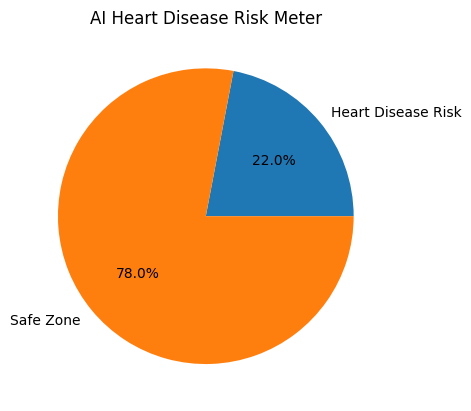



Do you want to test another patient? (yes/no): no.

System Closed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import numpy as np
import matplotlib.pyplot as plt

def show_risk_meter(risk):
    plt.figure()
    levels = [risk, 100-risk]
    labels = ["Heart Disease Risk", "Safe Zone"]
    plt.pie(levels, labels=labels, autopct='%1.1f%%')
    plt.title("AI Heart Disease Risk Meter")
    plt.show()

model_path = "/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl"

with open(model_path, "rb") as file:
    data = pickle.load(file)

if isinstance(data, dict):
    model = data["model"]
else:
    model = data

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)[0][1]

    risk_adjustment = 0

    if age > 60:
        risk_adjustment += 0.10

    if trestbps > 150:
        risk_adjustment += 0.10

    if chol > 250:
        risk_adjustment += 0.10

    if oldpeak > 3:
        risk_adjustment += 0.20

    if ca >= 2:
        risk_adjustment += 0.20

    if exang == 1:
        risk_adjustment += 0.10

    if thal == 2:
        risk_adjustment += 0.10

    probability = min(probability + risk_adjustment, 1)

    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

        print("\033[92mLOW RISK\033[0m")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

        print("\033[93mMODERATE RISK\033[0m")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

        print("\033[91mHIGH RISK\033[0m")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    show_risk_meter(risk_percent)

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

        ENTER PATIENT DETAILS

Age (years) [0–130]: 20
Sex (0 = Female, 1 = Male): 0
Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): 1
Resting Blood Pressure (mm Hg) [80–250]: 200
Serum Cholesterol Level (mg/dL) [100–600]: 120
Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): 1
Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): 0
Maximum Heart Rate Achieved (bpm) [60–220]: 78
Exercise Induced Angina (0 = No, 1 = Yes): 1
ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: 0.0
Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): 2
Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: 2
Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): 3

      AI CARDIOVASCULAR DIAGNO

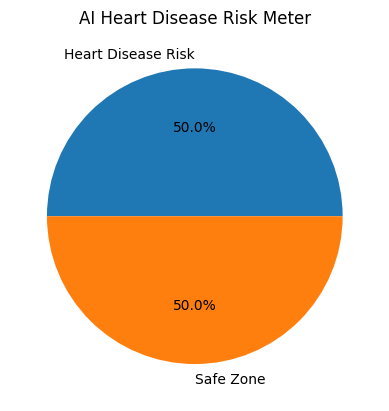

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import numpy as np
import matplotlib.pyplot as plt

def show_risk_meter(risk):
    plt.figure()
    levels = [risk, 100-risk]
    labels = ["Heart Disease Risk", "Safe Zone"]
    plt.pie(levels, labels=labels, autopct='%1.1f%%')
    plt.title("AI Heart Disease Risk Meter")
    plt.show()

model_path = "/content/drive/MyDrive/Colab Notebooks/heart_ai_system (1).pkl"

with open(model_path, "rb") as file:
    data = pickle.load(file)

if isinstance(data, dict):
    model = data["model"]
else:
    model = data

while True:

    print("\n===========================================")
    print("        ENTER PATIENT DETAILS")
    print("===========================================\n")

    age = int(input("Age (years) [0–130]: "))
    sex = int(input("Sex (0 = Female, 1 = Male): "))

    cp = int(input("Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic): "))
    trestbps = int(input("Resting Blood Pressure (mm Hg) [80–250]: "))
    chol = int(input("Serum Cholesterol Level (mg/dL) [100–600]: "))
    fbs = int(input("Fasting Blood Sugar > 120 mg/dL (0 = No, 1 = Yes): "))

    restecg = int(input("Resting Electrocardiographic Result (0 = Normal, 1 = ST-T Abnormality, 2 = Left Ventricular Hypertrophy): "))
    thalach = int(input("Maximum Heart Rate Achieved (bpm) [60–220]: "))
    exang = int(input("Exercise Induced Angina (0 = No, 1 = Yes): "))

    oldpeak = float(input("ST Depression Induced by Exercise Relative to Rest (Oldpeak) [0.0–10.0]: "))

    slope = int(input("Slope of Peak Exercise ST Segment (0 = Upsloping, 1 = Flat, 2 = Downsloping): "))
    ca = int(input("Number of Major Blood Vessels Colored by Fluoroscopy [0–4]: "))

    thal = int(input("Thalassemia Status (0 = Normal, 1 = Fixed Defect, 2 = Reversible Defect, 3 = Unknown): "))

    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                              restecg, thalach, exang, oldpeak,
                              slope, ca, thal]])

    prediction = model.predict(patient_data)
    probability = model.predict_proba(patient_data)[0][1]

    risk_adjustment = 0

    if age > 60:
        risk_adjustment += 0.10

    if trestbps > 150:
        risk_adjustment += 0.10

    if chol > 250:
        risk_adjustment += 0.10

    if oldpeak > 3:
        risk_adjustment += 0.20

    if ca >= 2:
        risk_adjustment += 0.20

    if exang == 1:
        risk_adjustment += 0.10

    if thal == 2:
        risk_adjustment += 0.10

    probability = min(probability + risk_adjustment, 1)

    risk_percent = round(probability * 100, 2)

    print("\n===========================================")
    print("      AI CARDIOVASCULAR DIAGNOSTIC REPORT")
    print("===========================================\n")

    if probability < 0.30:

        print("Prediction Status: NO SIGNIFICANT RISK")
        print("Risk Level: LOW")
        print("Health Indicator Level: GREEN")

        print("\nMedical Interpretation:")
        print("Heart parameters appear within normal range")

        print("\nRecommendation:")
        print("Maintain healthy lifestyle and regular checkups")

        print("\033[92mLOW RISK\033[0m")

    elif probability < 0.60:

        print("Prediction Status: MILD RISK")
        print("Risk Level: MODERATE")
        print("Health Indicator Level: YELLOW")

        print("\nMedical Interpretation:")
        print("Early cardiovascular stress indicators present")

        print("\nRecommendation:")
        print("Lifestyle improvement and physician consultation advised")

        print("\033[93mMODERATE RISK\033[0m")

    else:

        print("Prediction Status: HIGH RISK")
        print("Risk Level: CRITICAL")
        print("Health Indicator Level: RED")

        print("\nMedical Interpretation:")
        print("Strong indicators of potential heart disease")

        print("\nRecommendation:")
        print("Immediate medical evaluation recommended")

        print("\033[91mHIGH RISK\033[0m")

    print("\nEstimated Heart Disease Risk:", risk_percent, "%")

    print("\nSuggested Preventive Measures:")

    if chol > 240:
        print("- Reduce cholesterol intake")

    if trestbps > 140:
        print("- Monitor blood pressure regularly")

    if fbs == 1:
        print("- Control blood sugar level")

    if exang == 1:
        print("- Avoid heavy physical exertion")

    print("- Maintain regular exercise")
    print("- Follow balanced diet")

    show_risk_meter(risk_percent)

    print("\n===========================================\n")

    again = input("Do you want to test another patient? (yes/no): ")

    if again.lower() != "yes":
        print("\nSystem Closed.")
        break